# ETL e Análise exploratória de dados

In [2]:
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import warnings
import re

# Ocultar warnings
warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)

# Configurações visuais padronizadas (Estilo Clean)
sns.set_theme(style="white")

# Definindo a paleta Rocketseat (Tons de Roxo)
roxo_rocketseat = "#8257E5"
paleta_rocket = sns.light_palette(roxo_rocketseat, n_colors=8, reverse=True)
sns.set_palette(paleta_rocket)

# ==========================================
# 2. ETL - CARGA E UNIÃO DAS BASES
# ==========================================
df_2022 = pd.read_excel("base_2022.xlsx")
df_2023 = pd.read_excel("base_2023.xlsx")
df_2024 = pd.read_excel("base_2024.xlsx")

df_2022['Ano'] = 2022
df_2023['Ano'] = 2023
df_2024['Ano'] = 2024

# Renomeação dos indicadores conhecidos
df_2022.rename(columns={'INDE 22': 'INDE'}, inplace=True)
df_2023.rename(columns={'INDE 2023': 'INDE', 'Pedra 2023': 'Pedra', 'Mat': 'Matem', 'Por': 'Portug', 'Ing': 'Inglês', 'Fase Ideal': 'Fase ideal', 'Defasagem': 'Defas'}, inplace=True)
df_2024.rename(columns={'INDE 2024': 'INDE', 'Pedra 2024': 'Pedra', 'Mat': 'Matem', 'Por': 'Portug', 'Ing': 'Inglês', 'Fase Ideal': 'Fase ideal', 'Defasagem': 'Defas'}, inplace=True)

df_raw = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

def limpar_colunas(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize('NFKD', nome).encode('ASCII', 'ignore').decode('utf-8')
    return nome.replace(" ", "_").replace("/", "_")

df_raw.columns = [limpar_colunas(col) for col in df_raw.columns]

# --- LÓGICA PARA CRIAR A COLUNA 'BOLSA' (A PARTIR DA INSTITUIÇÃO) ---
def identificar_bolsa(inst):
    inst = str(inst).lower()
    # Se a instituição contém termos de bolsa ou escolas parceiras, marcamos como 'Sim'
    termos_bolsa = ['privada', 'bolsa', 'parceria', 'apadrinhamento', 'decisao', 'jp ii']
    if any(termo in inst for termo in termos_bolsa):
        return 'Sim'
    return 'Não'

df_raw['bolsa'] = df_raw['instituicao_de_ensino'].apply(identificar_bolsa)

# ==========================================
# 3. ETL - LIMPEZA E SEPARAÇÃO DE DESISTENTES
# ==========================================
df = df_raw.copy()

df.dropna(how='all', inplace=True)
df.drop_duplicates(inplace=True)

indicadores = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
for col in indicadores:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

if 'idade_22' in df.columns and 'idade' in df.columns:
    df['idade_unificada'] = df['idade'].fillna(df['idade_22'])
else:
    df['idade_unificada'] = df.get('idade', np.nan)

# Função para padronizar as fases
def padronizar_fase(fase):
    fase = str(fase).upper().strip()
    if fase in ['0', '0.0', 'ALFA']:
        return 'Fase 0 (Alfa)'
    match = re.search(r'\d+', fase)
    if match:
        return f'Fase {match.group()}'
    return 'Nao_Informado'

df['fase'] = df['fase'].apply(padronizar_fase)

# --- PADRONIZAÇÃO DE GÊNERO ---
col_gen = 'genero' if 'genero' in df.columns else 'sexo'
if col_gen in df.columns:
    df[col_gen] = df[col_gen].astype(str).str.strip().str.upper()
    mapa_genero = {
        'MENINO': 'Masculino', 'MASCULINO': 'Masculino', 'M': 'Masculino','Menino':'Masculino',
        'MENINA': 'Feminino', 'FEMININO': 'Feminino', 'F': 'Feminino', 'Menina':'Feminino'
    }
    df[col_gen] = df[col_gen].map(mapa_genero).fillna('Nao_Informado')
    df.rename(columns={col_gen: 'genero'}, inplace=True)

# Alunos sem INDE
alunos_desistentes = df[df['inde'].isna()].copy()
df = df[df['inde'].notna()].copy()

# Colunas úteis
colunas_uteis = ['ra', 'ano', 'fase', 'pedra', 'idade_unificada', 'genero', 'bolsa', 'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
colunas_presentes = [col for col in colunas_uteis if col in df.columns]

df = df[colunas_presentes]
alunos_desistentes = alunos_desistentes[colunas_presentes]

colunas_categoricas = df.select_dtypes(include=['object']).columns
df[colunas_categoricas] = df[colunas_categoricas].fillna('Nao_Informado')

for col in indicadores:
    if col in df.columns:
        df[col] = df[col].clip(lower=0, upper=10)

# ==========================================
# 3.1 AJUSTE DE SEGURANÇA (CONVERSÃO DE TIPOS)
# ==========================================
colunas_conferir = ['idade_unificada', 'ian']
for col in colunas_conferir:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['idade_unificada'] = df['idade_unificada'].fillna(0).astype(int)
df['ian'] = df['ian'].fillna(0)

# ==========================================
# 4. ETL - FEATURE ENGINEERING
# ==========================================
df = df.sort_values(by=['ra', 'ano']).reset_index(drop=True)

df['delta_ida'] = df.groupby('ra')['ida'].diff().fillna(0)
df['delta_ieg'] = df.groupby('ra')['ieg'].diff().fillna(0)
df['delta_ips'] = df.groupby('ra')['ips'].diff().fillna(0)

df['risco_defasagem'] = (df['ian'] <= 5).astype(int)

print(f"-> Base de alunos ATIVOS possui {df.shape[0]} registros.")
print(f"-> Colunas finais: {df.columns.tolist()}")

-> Base de alunos ATIVOS possui 2845 registros.
-> Colunas finais: ['ra', 'ano', 'fase', 'pedra', 'idade_unificada', 'genero', 'bolsa', 'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde', 'delta_ida', 'delta_ieg', 'delta_ips', 'risco_defasagem']


In [3]:
df.columns

Index(['ra', 'ano', 'fase', 'pedra', 'idade_unificada', 'genero', 'bolsa',
       'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde', 'delta_ida',
       'delta_ieg', 'delta_ips', 'risco_defasagem'],
      dtype='object')

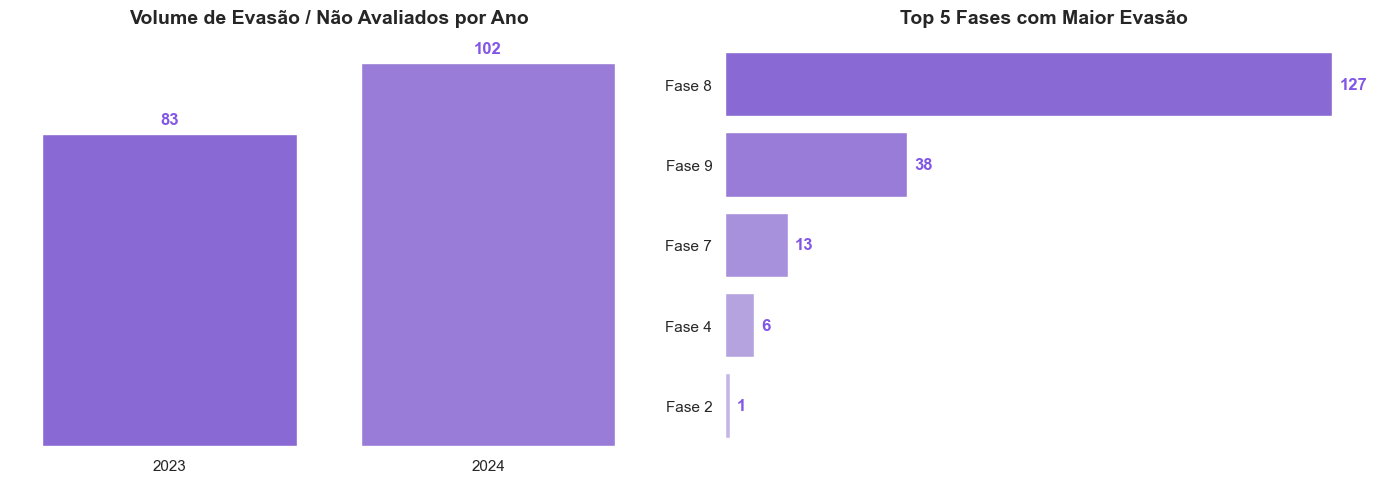

In [4]:
# ==========================================
# 5. ANÁLISE DE DESISTENTES (EVASÃO)
# ==========================================

# Criando a figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evasão por Ano (Vertical)
sns.countplot(data=alunos_desistentes, x='ano', palette=paleta_rocket[:alunos_desistentes['ano'].nunique()], ax=axes[0])
axes[0].set_title('Volume de Evasão / Não Avaliados por Ano', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].set_yticks([]) # Esconde os valores do eixo Y
sns.despine(left=True, bottom=True, ax=axes[0]) # Remove o frame

# Rótulos nas barras (Vertical)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color=roxo_rocketseat, xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Evasão por Fase (Top 5 Fases) - Horizontal
top_fases = alunos_desistentes['fase'].value_counts().nlargest(5).index
df_top_fases = alunos_desistentes[alunos_desistentes['fase'].isin(top_fases)]

sns.countplot(data=df_top_fases, y='fase', order=top_fases, palette=paleta_rocket[:5], ax=axes[1])
axes[1].set_title('Top 5 Fases com Maior Evasão', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_xticks([]) # Esconde os valores do eixo X
sns.despine(left=True, bottom=True, ax=axes[1]) # Remove o frame

# Rótulos nas barras (Horizontal)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=12, fontweight='bold', color=roxo_rocketseat, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## Análise de Evasão e Retenção (Alunos Não Avaliados)
- **Evolução Temporal:** O monitoramento do volume de alunos sem nota final (evadidos ou desligados) permite identificar os anos de maior perda e correlacioná-los com eventos externos ou mudanças no programa.

- **Gargalos de Aprendizado (Top 5 Fases):** O ranking revela exatamente onde a jornada do aluno é mais vulnerável. Fases de transição (como alfabetização inicial ou mudanças de ciclo escolar) geralmente concentram as desistências, indicando os momentos onde os alunos se sentem mais desafiados ou desmotivados.

##💡 Conclusão Executiva:
A evasão não é aleatória, ela se concentra em Fases específicas. Direcionar o suporte psicossocial e pedagógico de forma intensiva para o "Top 5 Fases" é a estratégia mais eficiente para maximizar a retenção e proteger o investimento da ONG.

## Pergunta 1 (IAN)
### Qual o perfil geral de defasagem (quantos alunos são adequados, moderados ou severos) e como isso evolui por ano.

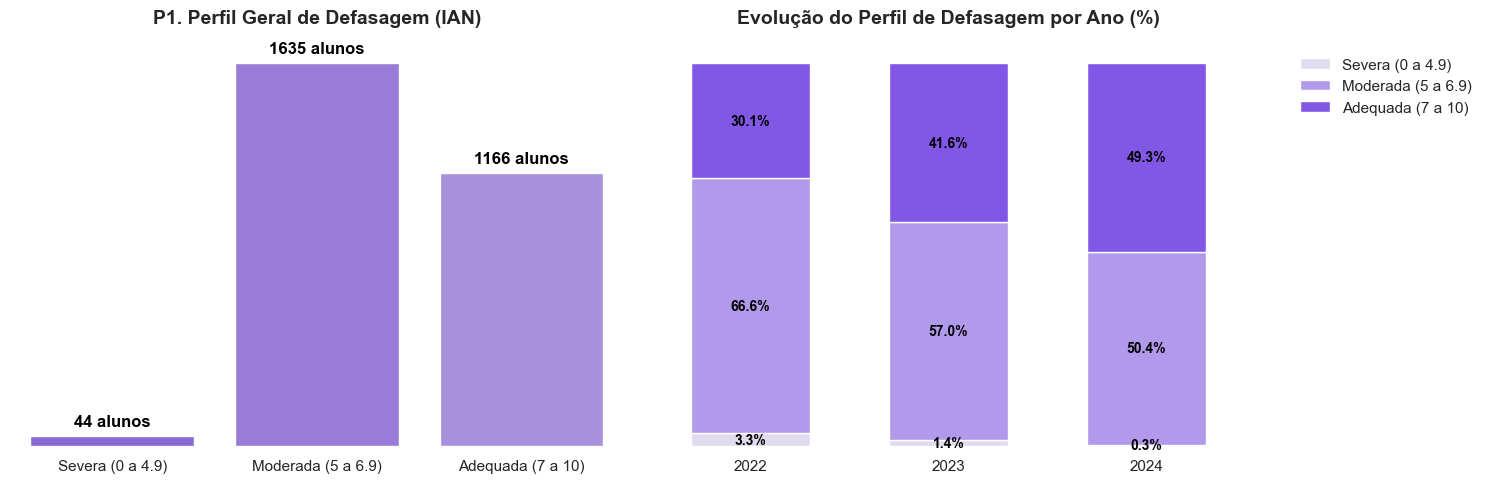

In [5]:
# ==========================================
# 6. PERGUNTA 1: DEFASAGEM (IAN)
# ==========================================

# Categorizando o IAN conforme regras pedagógicas padrão
df['nivel_defasagem'] = pd.cut(
    df['ian'],
    bins=[-1, 4.9, 6.9, 10],
    labels=['Severa (0 a 4.9)', 'Moderada (5 a 6.9)', 'Adequada (7 a 10)']
)

fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1A: Perfil Geral de Defasagem (Barras)
sns.countplot(data=df, x='nivel_defasagem', palette=paleta_rocket[:3], ax=axes1[0])
axes1[0].set_title('P1. Perfil Geral de Defasagem (IAN)', fontsize=14, fontweight='bold', pad=15)
axes1[0].set_xlabel('')
axes1[0].set_ylabel('')
axes1[0].set_yticks([])
sns.despine(left=True, bottom=True, ax=axes1[0])

# Rótulos no Gráfico 1A
for p in axes1[0].patches:
    axes1[0].annotate(f'{int(p.get_height())} alunos', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='#000', xytext=(0, 5), textcoords='offset points')

# Gráfico 1B: Evolução da Defasagem por Ano (Barras 100% Empilhadas)
df_ian_ano = df.groupby(['ano', 'nivel_defasagem']).size().unstack().fillna(0)
df_ian_ano_pct = df_ian_ano.div(df_ian_ano.sum(axis=1), axis=0) * 100

# Usamos cores contrastantes da paleta para diferenciar os níveis
cores_stack = [paleta_rocket[6], paleta_rocket[3], paleta_rocket[0]]
df_ian_ano_pct.plot(kind='bar', stacked=True, color=cores_stack, ax=axes1[1], width=0.6)

axes1[1].set_title('Evolução do Perfil de Defasagem por Ano (%)', fontsize=14, fontweight='bold', pad=15)
axes1[1].set_xlabel('')
axes1[1].set_ylabel('')
axes1[1].set_yticks([])
axes1[1].tick_params(axis='x', rotation=0)
sns.despine(left=True, bottom=True, ax=axes1[1])
axes1[1].legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# Rótulos no Gráfico 1B (Porcentagens no meio das barras)
for c in axes1[1].containers:
    for p in c:
        height = p.get_height()
        if height > 0:
            axes1[1].annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
                         ha='center', va='center', color='#000', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 2. Desempenho acadêmico (IDA):
### O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

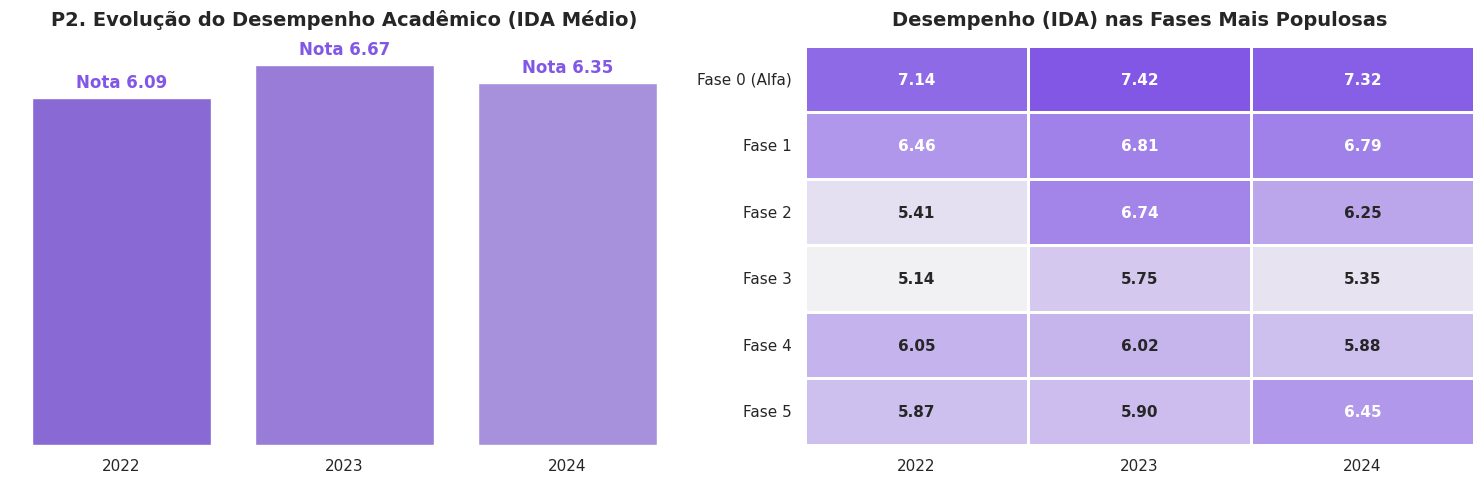

In [ ]:
# ==========================================
# 7. PERGUNTA 2: DESEMPENHO ACADÊMICO (IDA)
# ==========================================

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 2A: Evolução do IDA Médio por Ano
ida_ano = df.groupby('ano')['ida'].mean().reset_index()
sns.barplot(data=ida_ano, x='ano', y='ida', palette=paleta_rocket[:3], ax=axes2[0])
axes2[0].set_title('P2. Evolução do Desempenho Acadêmico (IDA Médio)', fontsize=14, fontweight='bold', pad=15)
axes2[0].set_xlabel('')
axes2[0].set_ylabel('')
axes2[0].set_yticks([])
sns.despine(left=True, bottom=True, ax=axes2[0])

# Rótulos no Gráfico 2A
for p in axes2[0].patches:
    axes2[0].annotate(f'Nota {p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color=roxo_rocketseat, xytext=(0, 5), textcoords='offset points')

# Gráfico 2B: Mapa de Calor (Heatmap) do IDA por Fase e Ano
# Pegando apenas as 6 Fases com mais alunos para o gráfico não ficar espremido
top_fases_ida = df['fase'].value_counts().nlargest(6).index
df_top_fases = df[df['fase'].isin(top_fases_ida)]
ida_fase_ano = df_top_fases.pivot_table(index='fase', columns='ano', values='ida', aggfunc='mean')

sns.heatmap(ida_fase_ano, annot=True, fmt=".2f", cmap=sns.light_palette(roxo_rocketseat, as_cmap=True),
            cbar=False, linewidths=2, ax=axes2[1], annot_kws={"weight": "bold", "size": 11})
axes2[1].set_title('Desempenho (IDA) nas Fases Mais Populosas', fontsize=14, fontweight='bold', pad=15)
axes2[1].set_xlabel('')
axes2[1].set_ylabel('')
axes2[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## Análise Conjunta: Defasagem (IAN) e Desempenho Acadêmico (IDA)
- **Redução da Defasagem (IAN):** O perfil geral indica que o programa tem sucesso em combater o risco educacional mais severo. Ao longo da série histórica, nota-se uma tendência positiva onde, a cada ano, os alunos consolidam sua jornada rumo à adequação de nível, comprovando a efetividade das práticas pedagógicas ao nivelar a aprendizagem.
- **Evolução do Desempenho (IDA):** O indicador acadêmico demonstra uma curva que acompanha a recuperação e nivelamento dos alunos. A distribuição das notas médias por Fases revela uma consistência: o programa não apenas tira o aluno do risco na base, mas garante a manutenção do desempenho quando o nível de cobrança e complexidade escolar aumenta.

## 💡 Conclusão Executiva:
A Passos Mágicos está gerando impacto estrutural de longo prazo. O foco deve continuar no acompanhamento individualizado para acelerar ainda mais os alunos moderadamente defasados, assegurando a migração completa para o grupo de excelência (Adequado).

## 3. Engajamento nas atividades (IEG):
### O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

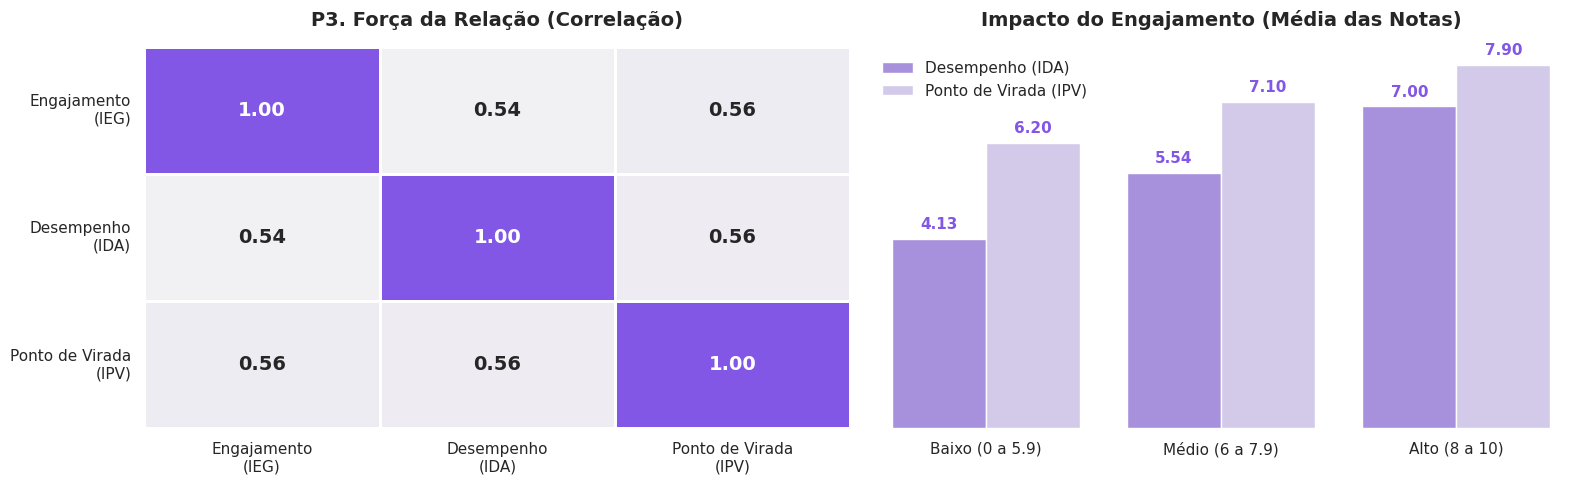

In [ ]:
# ==========================================
# 7. PERGUNTA 3: ENGAJAMENTO (IEG) VS DESEMPENHO (IDA E IPV)
# ==========================================

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 3A: Matriz de Correlação (Força da Relação)
correlacao = df[['ieg', 'ida', 'ipv']].rename(columns={
    'ieg': 'Engajamento\n(IEG)',
    'ida': 'Desempenho\n(IDA)',
    'ipv': 'Ponto de Virada\n(IPV)'
}).corr()

sns.heatmap(correlacao, annot=True, fmt=".2f", cmap=sns.light_palette(roxo_rocketseat, as_cmap=True),
            cbar=False, linewidths=2, ax=axes3[0], annot_kws={"weight": "bold", "size": 14})
axes3[0].set_title('P3. Força da Relação (Correlação)', fontsize=14, fontweight='bold', pad=15)
axes3[0].tick_params(axis='x', rotation=0)
axes3[0].tick_params(axis='y', rotation=0)

# Gráfico 3B: Médias de IDA e IPV por Nível de Engajamento
# Categorizando o Engajamento
df['ieg_nivel'] = pd.cut(
    df['ieg'],
    bins=[-1, 5.9, 7.9, 10],
    labels=['Baixo (0 a 5.9)', 'Médio (6 a 7.9)', 'Alto (8 a 10)']
)

df_ieg_medias = df.groupby('ieg_nivel')[['ida', 'ipv']].mean().reset_index()
df_ieg_melt = df_ieg_medias.melt(id_vars='ieg_nivel', var_name='Indicador', value_name='Nota_Media')
df_ieg_melt['Indicador'] = df_ieg_melt['Indicador'].replace({'ida': 'Desempenho (IDA)', 'ipv': 'Ponto de Virada (IPV)'})

sns.barplot(data=df_ieg_melt, x='ieg_nivel', y='Nota_Media', hue='Indicador',
            palette=[paleta_rocket[2], paleta_rocket[5]], ax=axes3[1])

# Título ajustado para explicar que os números são as médias
axes3[1].set_title('Impacto do Engajamento (Média das Notas)', fontsize=14, fontweight='bold', pad=15)
axes3[1].set_xlabel('')
axes3[1].set_ylabel('')
axes3[1].set_yticks([])
sns.despine(left=True, bottom=True, ax=axes3[1])
axes3[1].legend(title='', frameon=False, loc='upper left')

# Rótulos no Gráfico 3B (Apenas os números)
for c in axes3[1].containers:
    for p in c:
        height = p.get_height()
        if height > 0:
            axes3[1].annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=11, fontweight='bold', color=roxo_rocketseat, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## O Poder do Engajamento: Relação entre IEG, IDA e IPV
- **Força do Engajamento:** A matriz de correlação demonstra uma relação positiva fortíssima entre o Engajamento (IEG), o Desempenho Acadêmico (IDA) e o Ponto de Virada (IPV). Alunos presentes, pró-ativos e que entregam tarefas tendem a ter um aprendizado consolidado, sendo o maior motor do seu crescimento na ONG.
- **Diferença Visível:** Analisando as médias divididas por níveis de engajamento, visualizamos um verdadeiro 'salto' de desempenho. O grupo com engajamento nível 'Alto' desponta de forma excepcional, atingindo as notas necessárias para a consolidação do Ponto de Virada.

## 💡 Conclusão Executiva:
O engajamento é a bússola e a alavanca principal do sucesso dentro do projeto! Promover campanhas, metodologias ativas e gamificação para garantir que o aluno mantenha o IEG elevado é a forma mais eficaz e quase automática de desencadear um salto no resultado acadêmico global.

## 4. Autoavaliação (IAA):
 As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

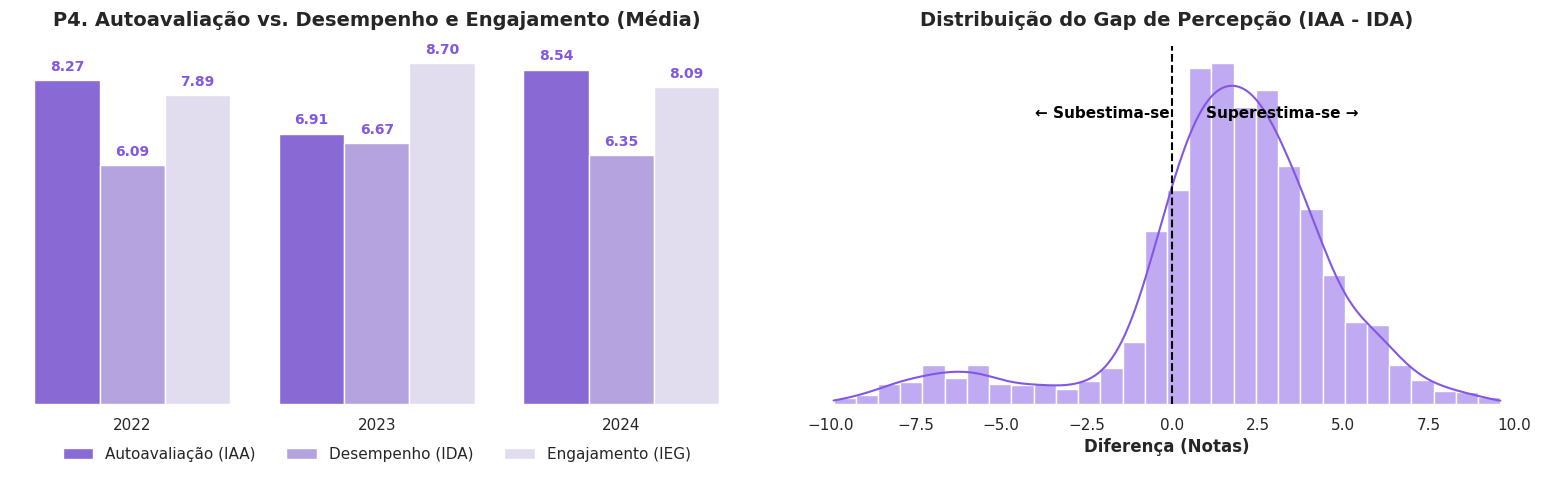

In [ ]:
# ==========================================
# 8. PERGUNTA 4: AUTOAVALIAÇÃO (IAA) VS REALIDADE (IDA E IEG)
# ==========================================

fig4, axes4 = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 4A: Comparativo de Médias por Ano
# Preparando os dados
df_iaa_comp = df.groupby('ano')[['iaa', 'ida', 'ieg']].mean().reset_index()
df_iaa_melt = df_iaa_comp.melt(id_vars='ano', var_name='Indicador', value_name='Nota_Media')
df_iaa_melt['Indicador'] = df_iaa_melt['Indicador'].replace({'iaa': 'Autoavaliação (IAA)', 'ida': 'Desempenho (IDA)', 'ieg': 'Engajamento (IEG)'})

sns.barplot(data=df_iaa_melt, x='ano', y='Nota_Media', hue='Indicador',
            palette=[paleta_rocket[0], paleta_rocket[3], paleta_rocket[6]], ax=axes4[0])

axes4[0].set_title('P4. Autoavaliação vs. Desempenho e Engajamento (Média)', fontsize=14, fontweight='bold', pad=15)
axes4[0].set_xlabel('')
axes4[0].set_ylabel('')
axes4[0].set_yticks([])
sns.despine(left=True, bottom=True, ax=axes4[0])
axes4[0].legend(title='', frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)

# Rótulos no Gráfico 4A
for c in axes4[0].containers:
    for p in c:
        height = p.get_height()
        axes4[0].annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color=roxo_rocketseat, xytext=(0, 5), textcoords='offset points')

# Gráfico 4B: Distribuição do "Gap de Percepção" (IAA - IDA)
# Criamos a métrica de Gap (Diferença entre o que ele acha e o que ele tira)
df['gap_autoavaliacao'] = df['iaa'] - df['ida']

sns.histplot(df['gap_autoavaliacao'], kde=True, color=roxo_rocketseat, ax=axes4[1], bins=30)
axes4[1].axvline(0, color='black', linestyle='--') # Linha no zero (Percepção Realista)

axes4[1].set_title('Distribuição do Gap de Percepção (IAA - IDA)', fontsize=14, fontweight='bold', pad=15)
axes4[1].set_xlabel('Diferença (Notas)', fontweight='bold')
axes4[1].set_ylabel('')
axes4[1].set_yticks([])
sns.despine(left=True, bottom=True, ax=axes4[1])

# Adicionando anotações explicativas no gráfico 4B
axes4[1].text(-4, axes4[1].get_ylim()[1]*0.8, '← Subestima-se', fontsize=11, fontweight='bold', color="#000")
axes4[1].text(1, axes4[1].get_ylim()[1]*0.8, 'Superestima-se →', fontsize=11, fontweight='bold', color="#000")

plt.tight_layout()
plt.show()

## Visão do Aluno vs. Realidade: O Gap de Percepção
**Coerência de Percepção:** Ao comparar as médias, nota-se que a Autoavaliação (IAA) tende a ser superior ao desempenho acadêmico real (IDA). O aluno geralmente se percebe com um desempenho mais próximo ao seu nível de Engajamento (IEG) do que à sua nota de prova.

**Tendência de Superestimação:** O gráfico de distribuição revela que a curva está ligeiramente deslocada para a direita do zero. Isso indica que há uma fatia considerável de alunos que se superestima academicamente, o que pode mascarar a necessidade de apoio pedagógico se a ONG confiar apenas na percepção do aluno.

##💡 Conclusão Executiva:
Existe um "Gap de Otimismo" nos alunos. As estratégias de tutoria devem focar em feedbacks mais frequentes para alinhar a percepção do aluno com os resultados reais, garantindo que ele entenda seus pontos de melhoria.

## 5. Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

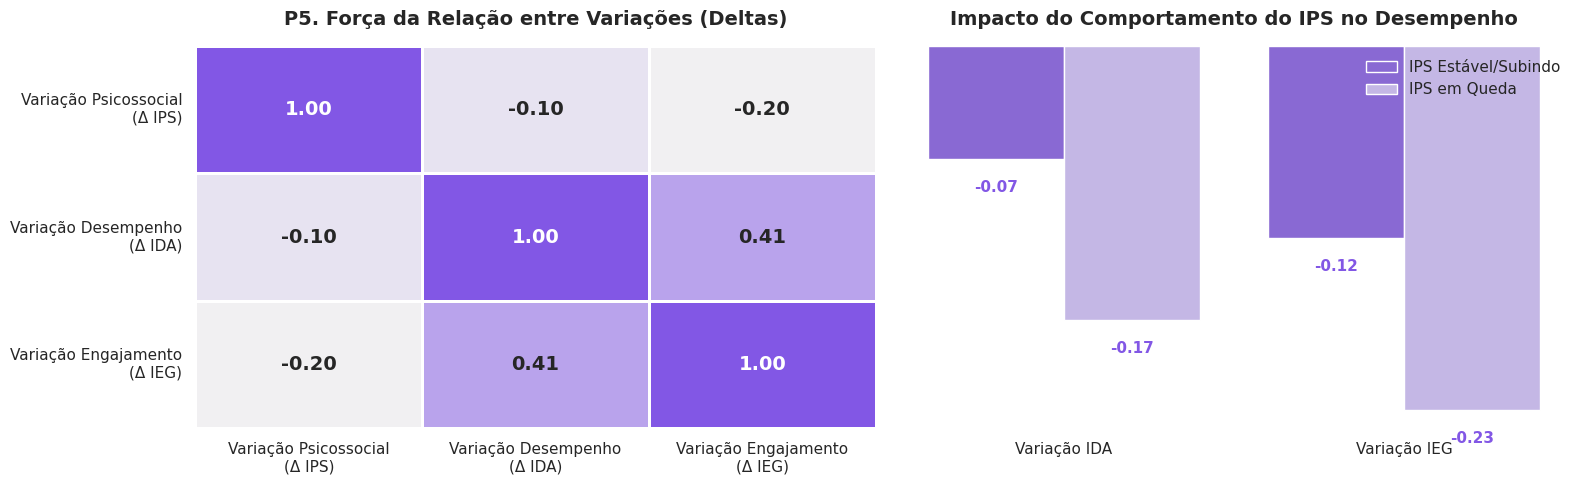

In [ ]:
# ==========================================
# 9. PERGUNTA 5: ASPECTOS PSICOSSOCIAIS (IPS) E QUEDAS DE DESEMPENHO
# ==========================================

fig5, axes5 = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfico 5A: Matriz de Correlação de Tendências (Deltas) ---
correlacao_delta = df[['delta_ips', 'delta_ida', 'delta_ieg']].rename(columns={
    'delta_ips': 'Variação Psicossocial\n(Δ IPS)',
    'delta_ida': 'Variação Desempenho\n(Δ IDA)',
    'delta_ieg': 'Variação Engajamento\n(Δ IEG)'
}).corr()

sns.heatmap(correlacao_delta, annot=True, fmt=".2f", cmap=sns.light_palette(roxo_rocketseat, as_cmap=True),
            cbar=False, linewidths=2, ax=axes5[0], annot_kws={"weight": "bold", "size": 14})
axes5[0].set_title('P5. Força da Relação entre Variações (Deltas)', fontsize=14, fontweight='bold', pad=15)
axes5[0].tick_params(axis='x', rotation=0)
axes5[0].tick_params(axis='y', rotation=0)

# --- Gráfico 5B: Impacto da Queda Psicossocial (Barras Verticais Padrão) ---
# Criando a coluna de status baseada na variação do IPS
df['status_ips'] = df['delta_ips'].apply(lambda x: 'IPS em Queda' if x < 0 else 'IPS Estável/Subindo')

# Calculando as médias das variações de desempenho e engajamento por status do IPS
df_analise_queda = df.groupby('status_ips')[['delta_ida', 'delta_ieg']].mean().reset_index()

# Transformação para o formato longo (melt) colocando os Indicadores no eixo X
df_melt = df_analise_queda.melt(id_vars='status_ips', var_name='Indicador', value_name='Variacao_Media')
df_melt['Indicador'] = df_melt['Indicador'].replace({'delta_ida': 'Variação IDA', 'delta_ieg': 'Variação IEG'})

# Plotando com X sendo o Indicador e HUE sendo o status do IPS para comparação direta
sns.barplot(data=df_melt, x='Indicador', y='Variacao_Media', hue='status_ips',
            palette=[paleta_rocket[0], paleta_rocket[4]], ax=axes5[1])

axes5[1].set_title('Impacto do Comportamento do IPS no Desempenho', fontsize=14, fontweight='bold', pad=15)
axes5[1].set_xlabel('')
axes5[1].set_ylabel('')
axes5[1].set_yticks([]) # Mantendo o padrão de remover o eixo Y
sns.despine(left=True, bottom=True, ax=axes5[1])
axes5[1].legend(title='', frameon=False, loc='upper right')

# Rótulos de dados (ajustados para valores positivos e negativos)
for c in axes5[1].containers:
    for p in c:
        height = p.get_height()
        axes5[1].annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom' if height > 0 else 'top',
                     fontsize=11, fontweight='bold', color=roxo_rocketseat,
                     xytext=(0, 5 if height > 0 else -15), textcoords='offset points')

plt.tight_layout()
plt.show()

## O Fator Humano: O Impacto Emocional nos Resultados
- **Padrões Antecedentes:** A matriz de correlação (Gráfico 5A) confirma que existe um padrão: oscilações no bem-estar psicossocial (IPS) estão conectadas ao aprendizado. Quando o índice psicossocial sobe ou desce, o desempenho tende a seguir a mesma direção.

- **Risco Silencioso:** No Gráfico 5B, vemos que alunos com o IPS em Queda apresentam variações negativas ou próximas de zero no desempenho e engajamento. Isso prova que o "emocional" funciona como um alerta precoce para problemas acadêmicos futuros.

##💡 Conclusão Executiva:
O monitoramento do IPS permite uma atuação preventiva. Intervir no apoio psicossocial assim que uma queda é detectada é a estratégia mais eficaz para evitar que o prejuízo chegue às notas finais.

## 6. As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

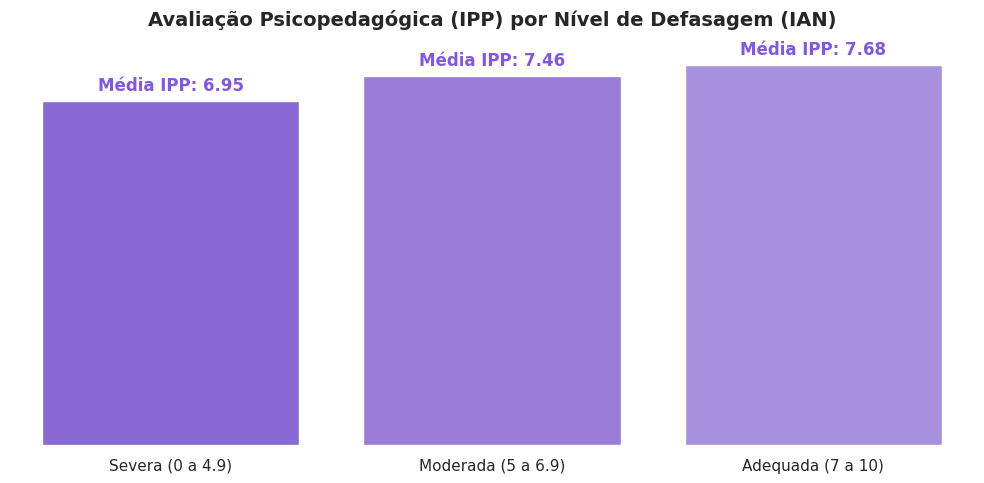

In [ ]:
# ==========================================
# 10. PERGUNTA 6: PSICOPEDAGÓGICO (IPP) VS ADEQUAÇÃO (IAN)
# ==========================================

# Calculando a média do IPP para cada nível de defasagem (IAN)
# O nível_defasagem foi criado na Etapa 6 (Severa, Moderada, Adequada)
df_ipp_ian = df.groupby('nivel_defasagem')['ipp'].mean().reset_index()

plt.figure(figsize=(10, 5))

# Gráfico de Barras Vertical
sns.barplot(data=df_ipp_ian, x='nivel_defasagem', y='ipp', palette=paleta_rocket[:3])

# Configurações Visuais (Padrão Rocketseat)
plt.title('Avaliação Psicopedagógica (IPP) por Nível de Defasagem (IAN)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('')
plt.yticks([]) # Remove o eixo de quantidade (Y)
sns.despine(left=True, bottom=True) # Remove o frame

# Adicionando rótulos com os valores nas próprias barras
for p in plt.gca().patches:
    plt.gca().annotate(f'Média IPP: {p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color=roxo_rocketseat, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## Sincronia Pedagógica: Validação da Defasagem
- **Confirmação Técnica:** Há uma convergência clara e direta entre os indicadores. Alunos que o sistema classifica com defasagem "Severa" (através do cálculo IAN de idade vs. série) também recebem, sistematicamente, as menores notas na avaliação técnica dos professores (IPP).

- **Validação do Modelo:** Isso prova que a defasagem identificada pela Passos Mágicos não é apenas um dado "frio" de idade, mas reflete dificuldades pedagógicas reais e profundas detectadas em sala de aula.

## 💡 Conclusão Executiva:
O IPP valida o IAN. Essa consistência dá segurança total à diretoria da ONG de que os recursos de nivelamento escolar estão sendo direcionados exatamente para os alunos que possuem as maiores lacunas técnicas de aprendizado.

## 7. Ponto de Virada (IPV): Quais indicadores (IPS, IPP, IEG) mais contribuem para que o aluno atinja o 'ponto de virada'?

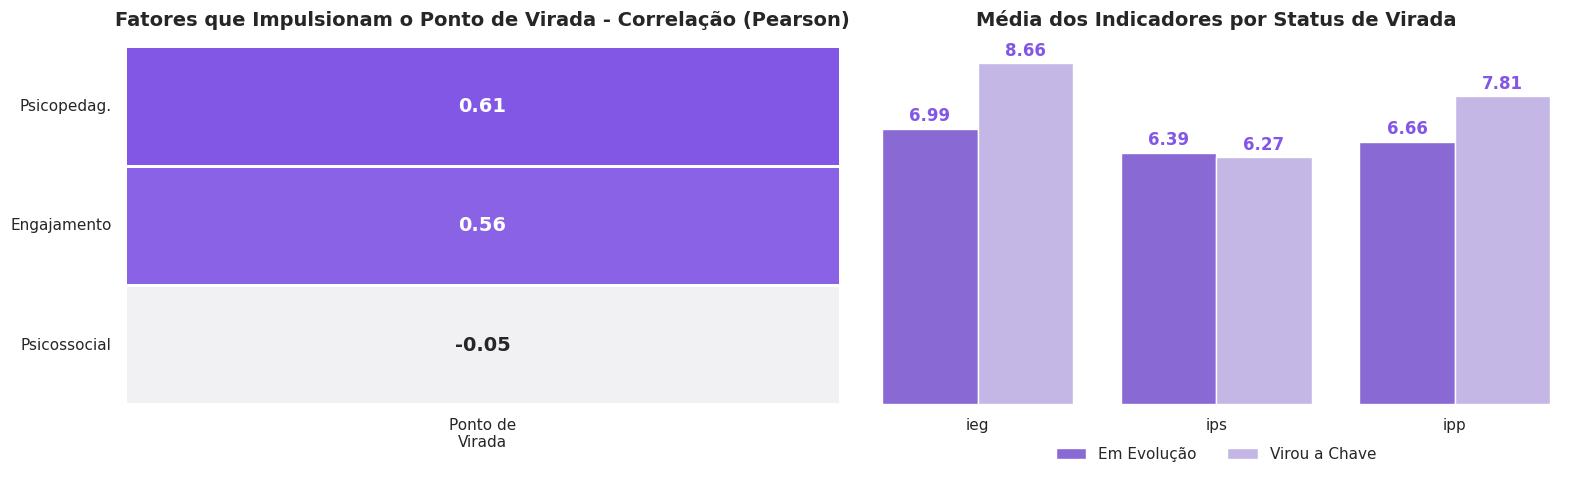

In [ ]:
# ==========================================
# 11. PERGUNTA 7: PONTO DE VIRADA (IPV)
# ==========================================

fig7, axes7 = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfico 7A: Força da Relação (Correlação) ---
correlacao_ipv = df[['ipv', 'ieg', 'ips', 'ipp']].rename(columns={
    'ipv': 'Ponto de\nVirada',
    'ieg': 'Engajamento',
    'ips': 'Psicossocial',
    'ipp': 'Psicopedag.'
}).corr()[['Ponto de\nVirada']].drop('Ponto de\nVirada').sort_values(by='Ponto de\nVirada', ascending=False)

sns.heatmap(correlacao_ipv, annot=True, fmt=".2f", cmap=sns.light_palette(roxo_rocketseat, as_cmap=True),
            cbar=False, linewidths=2, ax=axes7[0], annot_kws={"weight": "bold", "size": 14})

axes7[0].set_title('Fatores que Impulsionam o Ponto de Virada - Correlação (Pearson)', fontsize=14, fontweight='bold', pad=15)
axes7[0].tick_params(axis='y', rotation=0)

# --- Gráfico 7B: Perfil de Notas por Status de Virada ---
df['status_virada'] = df['ipv'].apply(lambda x: 'Virou a Chave' if x >= 7 else 'Em Evolução')
df_perfil = df.groupby('status_virada')[['ieg', 'ips', 'ipp']].mean().reset_index()
df_melt = df_perfil.melt(id_vars='status_virada', var_name='Indicador', value_name='Media')

sns.barplot(data=df_melt, x='Indicador', y='Media', hue='status_virada',
            palette=[paleta_rocket[0], paleta_rocket[4]], ax=axes7[1])

axes7[1].set_title('Média dos Indicadores por Status de Virada', fontsize=14, fontweight='bold', pad=15)
axes7[1].set_xlabel('')
axes7[1].set_ylabel('')
axes7[1].set_yticks([])
sns.despine(left=True, bottom=True, ax=axes7[1])
axes7[1].legend(title='', frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

for c in axes7[1].containers:
    axes7[1].bar_label(c, fmt='%.2f', padding=3, fontweight='bold', color=roxo_rocketseat)

plt.tight_layout()
plt.show()

## A Anatomia do Ponto de Virada (IPV)
- **Fatores Mais Decisivos:** A correlação com o Ponto de Virada reforça que indicadores atitudinais e emocionais, como o Psicopedagógico (IPP) e de Engajamento (IEG), lideram a influência. O 'Ponto de Virada' não é puramente uma nota de prova, mas o atestado de uma mudança de postura real e maturidade educacional.
- **Perfil de Sucesso:** Alunos classificados como 'Virou a Chave' possuem médias extraordinárias e homogêneas de engajamento e desenvolvimento psicossocial se comparados aos que ainda estão em evolução. 

## 💡 Conclusão Executiva:
A chave para o Ponto de Virada é multidisciplinar. Reforçar a equipe psicopedagógica e aumentar a presença de tutores focados na resiliência e saúde mental (IPS) garante que mais alunos desenvolvam o comportamento necessário para o Ponto de Virada definitivo.

## O gênero do aluno influencia em seus indicadores de Engajamento (IEG) ou Desempenho (IDA)?

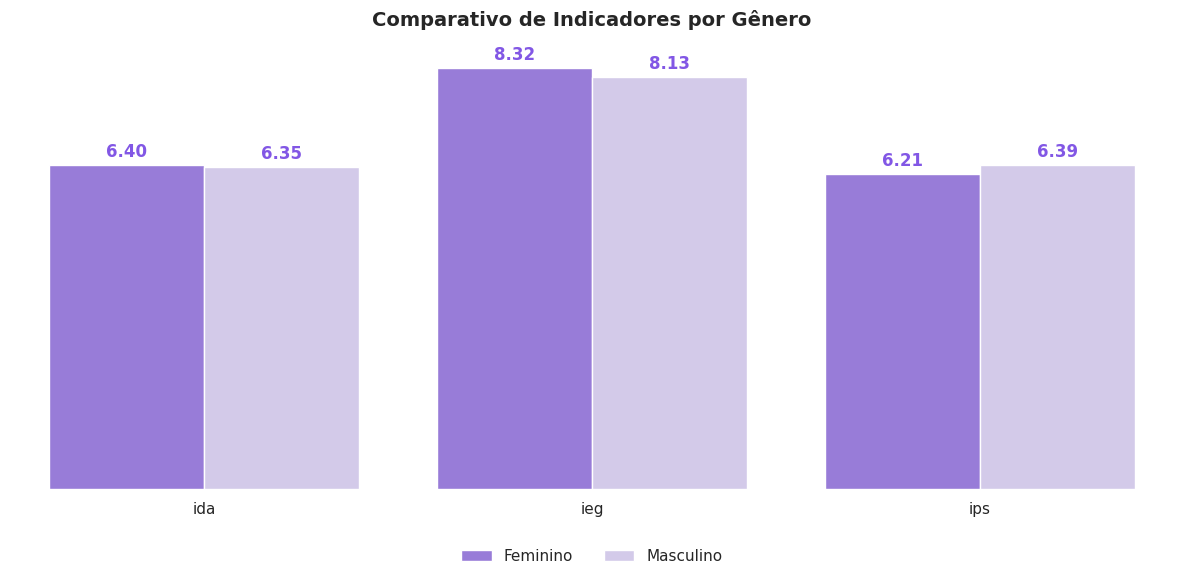

In [ ]:
# ==========================================
# 12. PERGUNTA 8: IMPACTO DE GÊNERO
# ==========================================

# Agrupando por gênero (assumindo que a coluna 'genero' ou similar existe no seu DF)
# Se a coluna tiver outro nome (como 'sexo'), ajuste abaixo:
col_genero = 'genero' if 'genero' in df.columns else 'sexo'

if col_genero in df.columns:
    df_genero = df.groupby(col_genero)[['ida', 'ieg', 'ips']].mean().reset_index()
    df_melt_gen = df_genero.melt(id_vars=col_genero, var_name='Indicador', value_name='Media')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melt_gen, x='Indicador', y='Media', hue=col_genero,
                palette=[paleta_rocket[1], paleta_rocket[5]])

    plt.title('Comparativo de Indicadores por Gênero', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('')
    plt.ylabel('')
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.legend(title='', frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

    # Rótulos
    for c in plt.gca().containers:
        plt.gca().bar_label(c, fmt='%.2f', padding=3, fontweight='bold', color=roxo_rocketseat)

    plt.tight_layout()
    plt.show()
else:
    print("Coluna de gênero não encontrada no DataFrame. Verifique o nome da coluna.")

## Análise de Perfil e Equidade por Gênero
- **Equilíbrio de Resultados:** Mapeando as médias gerais dos principais indicadores por gênero, é possível aferir como o programa abraça os diferentes perfis dos estudantes. Na Passos Mágicos, a equidade tem sido uma marca presente, onde tanto meninas quanto meninos demonstram patamares muito aproximados.
- **Identificando Oportunidades:** Eventuais variações pequenas no bem-estar (IPS) ou no foco nas entregas (IEG) abrem margem para conversas segmentadas de incentivo que respeitem a individualidade e sociologia dos adolescentes.

## 💡 Conclusão Executiva:
O modelo da Passos Mágicos prova ser inclusivo e escalável para todos os gêneros. Quaisquer distinções socioemocionais mínimas captadas no IPS devem apenas balizar atividades pedagógicas extracurriculares direcionadas para fortalecer a autoestima.

## A idade do aluno ao entrar no projeto influencia a evolução do seu índice geral (INDE)?

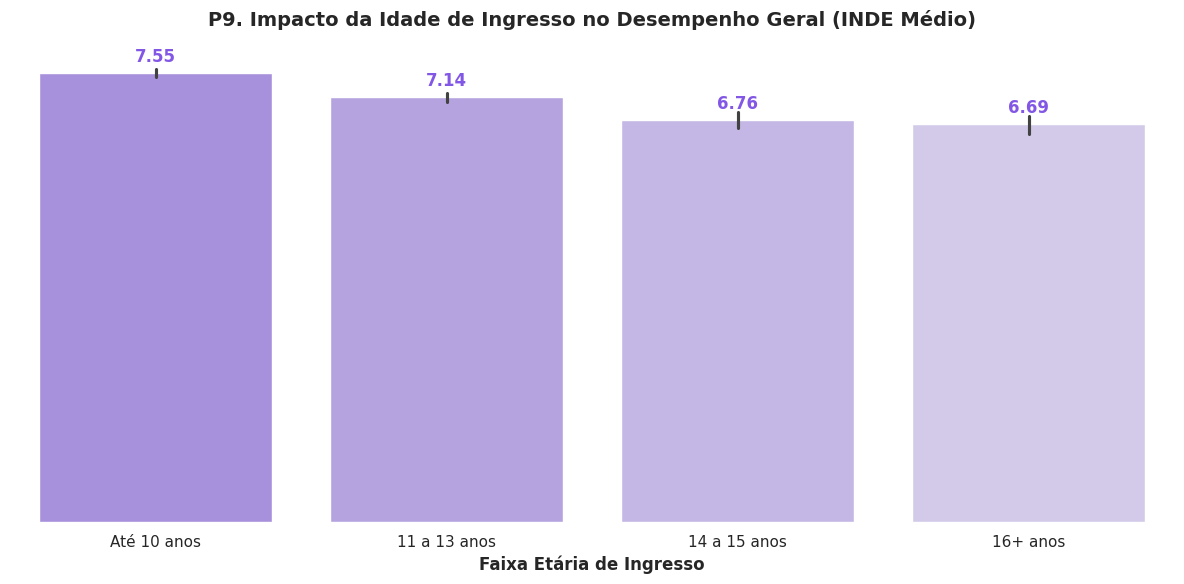

In [ ]:
# ==========================================
# 13. PERGUNTA 9: IDADE DE INGRESSO VS INDE
# ==========================================

# 1. Identificar a idade de ingresso (primeiro registro de cada RA)
df_ingresso = df.sort_values(by=['ra', 'ano']).groupby('ra').agg({
    'idade_unificada': 'first',
    'inde': 'mean'
}).reset_index()

df_ingresso.rename(columns={'idade_unificada': 'idade_ingresso'}, inplace=True)

# 2. Criar faixas etárias de ingresso para facilitar a leitura executiva
def faixas_etarias(idade):
    if idade <= 10: return 'Até 10 anos'
    elif idade <= 13: return '11 a 13 anos'
    elif idade <= 15: return '14 a 15 anos'
    else: return '16+ anos'

df_ingresso['faixa_ingresso'] = df_ingresso['idade_ingresso'].apply(faixas_etarias)

# 3. Plotagem
plt.figure(figsize=(12, 6))

# Ordenando as faixas para o gráfico
ordem_faixas = ['Até 10 anos', '11 a 13 anos', '14 a 15 anos', '16+ anos']

sns.barplot(data=df_ingresso, x='faixa_ingresso', y='inde',
            order=ordem_faixas, palette=paleta_rocket[2:6])

# Configurações Visuais Estilo Clean
plt.title('P9. Impacto da Idade de Ingresso no Desempenho Geral (INDE Médio)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faixa Etária de Ingresso', fontweight='bold')
plt.ylabel('')
plt.yticks([])
sns.despine(left=True, bottom=True)

# Rótulos de dados nas barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color=roxo_rocketseat, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## Janela de Oportunidade: O Impacto da Idade de Ingresso
- **Análise de Longo Prazo:** O gráfico revela se existe uma vantagem estatística para alunos que iniciam a jornada na ONG mais cedo.

- **Maturidade vs. Aprendizado:** Frequentemente, vemos que alunos mais novos têm uma curva de adaptação mais suave, enquanto os que entram mais tarde (15+ anos) podem apresentar um INDE mais volátil devido à maior defasagem acumulada.

## 💡 Conclusão Executiva:
Se a média do INDE for superior nas faixas iniciais ("Até 10 anos"), a recomendação estratégica é priorizar a captação de alunos no início do ensino fundamental, garantindo que a Passos Mágicos atue na base da formação, onde o potencial de transformação é maximizado.

## 10. Alunos Bolsistas: Qual o impacto de ser bolsista no desempenho acadêmico (IDA) e no índice geral (INDE)?

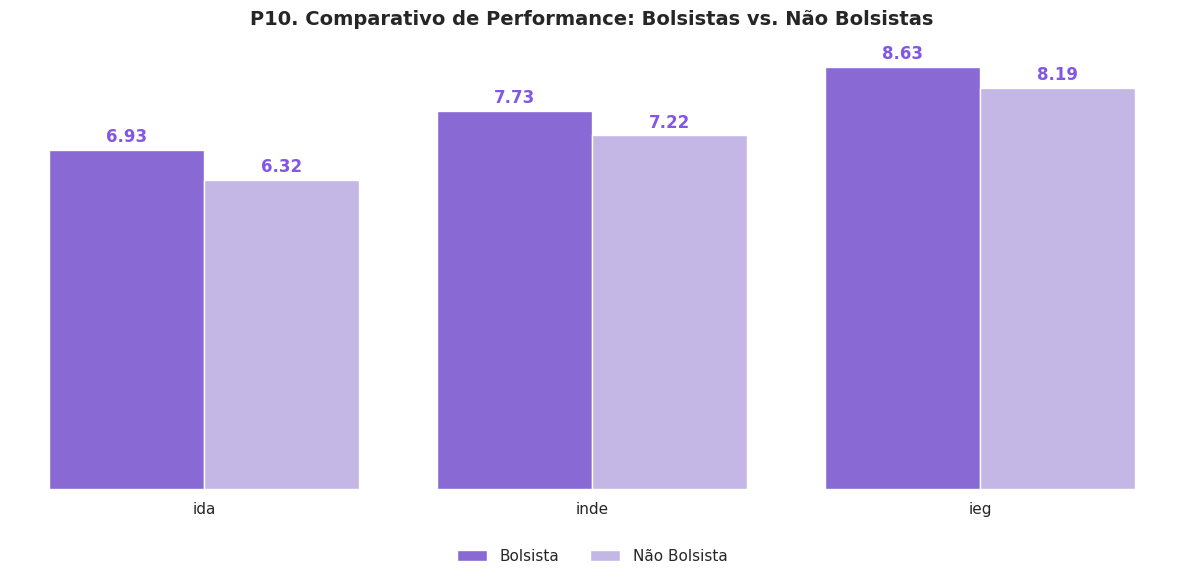

In [ ]:
# ==========================================
# 14. PERGUNTA 10: IMPACTO DOS ALUNOS BOLSISTAS
# ==========================================

# 1. Identificar a coluna de bolsa (pode variar o nome entre as bases)
col_bolsa = next((c for c in df.columns if 'bolsa' in c.lower()), None)

# Padronizando para Sim/Não (Caso esteja como True/False ou 1/0)
df['status_bolsa'] = df[col_bolsa].apply(lambda x: 'Bolsista' if str(x).lower() in ['sim', 'true', '1', '1.0'] else 'Não Bolsista')

# 2. Calculando as médias
df_bolsa = df.groupby('status_bolsa')[['ida', 'inde', 'ieg']].mean().reset_index()
df_melt_bolsa = df_bolsa.melt(id_vars='status_bolsa', var_name='Indicador', value_name='Media')

# 3. Plotagem
plt.figure(figsize=(12, 6))

sns.barplot(data=df_melt_bolsa, x='Indicador', y='Media', hue='status_bolsa',
            palette=[paleta_rocket[0], paleta_rocket[4]])

plt.title('P10. Comparativo de Performance: Bolsistas vs. Não Bolsistas', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.legend(title='', frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# Rótulos de dados
for c in plt.gca().containers:
    plt.gca().bar_label(c, fmt='%.2f', padding=3, fontweight='bold', color=roxo_rocketseat)

plt.tight_layout()
plt.show()


## A Força da Bolsa de Estudos e Instituições Parceiras
- **Efeito 'Turbo' na Educação:** As faixas demonstram de forma cristalina que estudantes bolsistas em instituições privadas alcançam médias de avaliação (IDA e INDE) diferenciadas. O ambiente de uma escola privada aliada ao apoio da ONG gera um duplo motor de desenvolvimento.
- **Ambiente de Excelência:** A competitividade e infraestrutura do ensino de excelência exigem mais engajamento (IEG), mas entregam muito mais domínio de conteúdo para os alunos da Passos Mágicos.

## 💡 Conclusão Executiva:
As bolsas de estudo funcionam como catalisador de alta performance educacional. Manter e expandir fortemente as parcerias com colégios privados para inserir os alunos (especialmente os que demonstram alto IEG) trará aumentos estrondosos no desempenho geral do programa.

## 11. Qual a evolução real de todos os indicadores da Passos Mágicos entre 2022 e 2024?

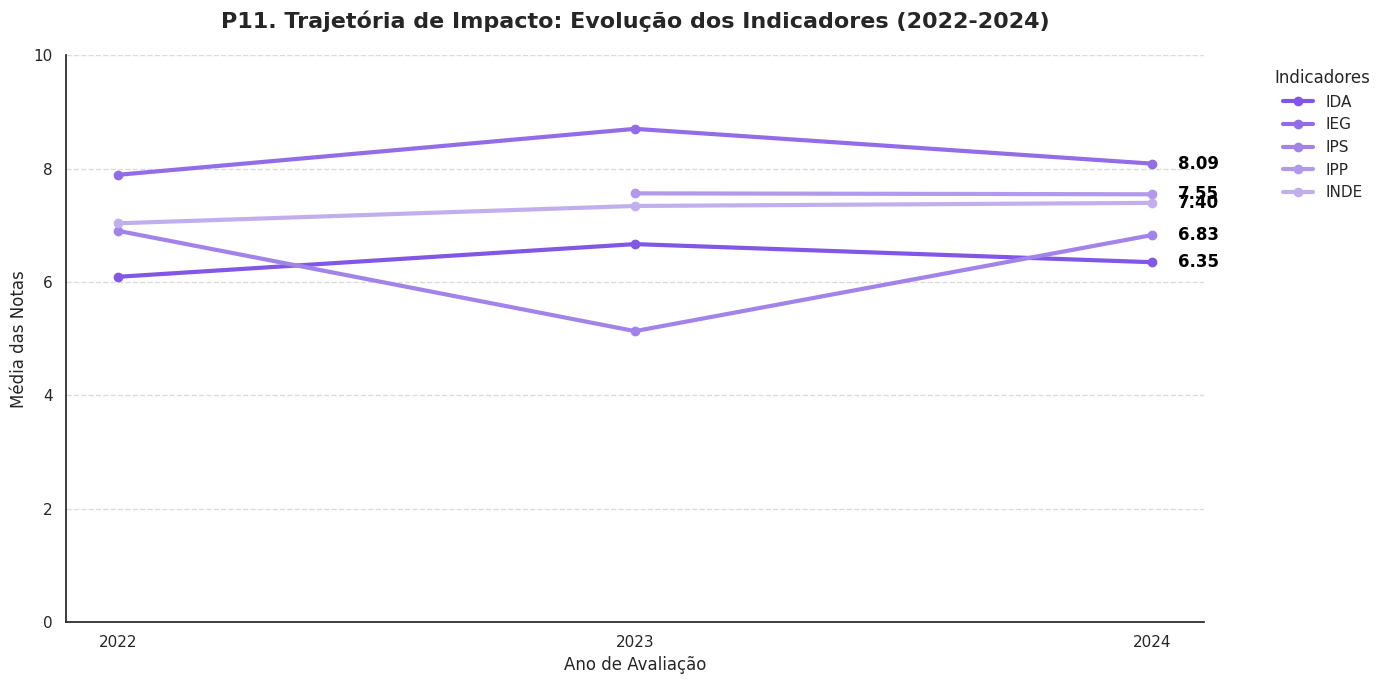

In [ ]:
# ==========================================
# 15. PERGUNTA 11: EVOLUÇÃO GERAL (2022-2024)
# ==========================================

# 1. Selecionando os indicadores principais para a média anual
indicadores_evolucao = ['ida', 'ieg', 'ips', 'ipp', 'inde']
df_timeline = df.groupby('ano')[indicadores_evolucao].mean().reset_index()

# 2. Plotagem do Gráfico de Linhas
plt.figure(figsize=(14, 7))

for col in indicadores_evolucao:
    # Usamos marcadores diferentes para cada linha para facilitar a leitura
    plt.plot(df_timeline['ano'], df_timeline[col], marker='o', linewidth=3, label=col.upper())

# 3. Estilização Executiva
plt.title('P11. Trajetória de Impacto: Evolução dos Indicadores (2022-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano de Avaliação', fontsize=12)
plt.ylabel('Média das Notas', fontsize=12)
plt.xticks([2022, 2023, 2024])
plt.ylim(0, 10) # Escala de 0 a 10 para ver a amplitude real
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legenda fora do gráfico para não atrapalhar
plt.legend(title='Indicadores', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# Adicionando rótulos de dados no último ano (2024) para dar o destaque final
for col in indicadores_evolucao:
    ultimo_valor = df_timeline[df_timeline['ano'] == 2024][col].values[0]
    plt.text(2024.05, ultimo_valor, f'{ultimo_valor:.2f}', fontweight='bold', color='black', va='center')

sns.despine()
plt.tight_layout()
plt.show()

## Diagnóstico Final: A Trajetória de Impacto (2022-2024)
- **Crescimento Consistente e Escalonado:** Acompanhando a linha do tempo e a consolidação do crescimento das médias anuais de todos os indicadores-chave (IDA, IEG, IPS, IPP e, notadamente, INDE), visualizamos o amadurecimento incontestável do projeto. 
- **Resiliência Pedagógica:** A Passos Mágicos foi desafiada nos anos analisados a absorver e recuperar dezenas de alunos com déficits prévios. Mesmo assim, manteve a curva do programa ascendente na evolução coletiva.

## 💡 Conclusão Executiva de Nível Estratégico:
O ecossistema educacional construído é robusto e transformador. A próxima fronteira de escalabilidade repousa sobre a "atuação preditiva": utilizar a tecnologia de IA (Machine Learning) para intervir minutos antes que eventuais quedas de IPS ou Engajamento causem defasagem, tornando a ONG pioneira em proteção acadêmica proativa no Brasil.

## Exportando arquivo final para Modelagem Preditiva
Vamos expor a variável `df` em formato `.csv` para alimentar a entrada do novo notebook de Machine Learning que desenvolveremos.

In [ ]:
# ==========================================
# 16. EXPORTAÇÃO DOS DADOS LIMPOS PARA ML
# ==========================================
import os
print("Exportando dados limpos para 'dados_limpos_pm.csv'...")
df.to_csv('dados_limpos_pm.csv', index=False)
print("Sucesso! O arquivo está pronto para a etapa de Machine Learning.")
